# Classificador Fuzzy SOME/IP — Pipeline Completo

Notebook de reproducao completa: do PCAP bruto ate as metricas finais.

**Ataque**: Fuzzy — *SD OfferService Flooding* + *ADAS Random Payload Injection*  
**Atacantes**: IP `172.18.0.17` (pcap1) e `172.18.0.12` (pcap2, pcap3)  
**Referencia**: Kim et al. (2026). XGBoost-Based Anomaly Detection for SOME/IP. Systems 14(2), 196.

In [1]:
import sys, subprocess, time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

FUZZY_DIR = Path().resolve()          # detection/fuzzy/
DET_DIR   = FUZZY_DIR.parent          # detection/
SRC_DIR   = DET_DIR / 'src'
PARSE_DIR = DET_DIR / 'data' / 'parsed'
RAW_DIR   = DET_DIR / 'data' / 'raw'
DATA_DIR  = FUZZY_DIR / 'data'
MODEL_DIR = FUZZY_DIR / 'model'

sys.path.insert(0, str(DET_DIR))

FEAT_COLS = [
    'f01_ip_time_interval', 'f08_someip_payload_change',
    'f11_ip_length_change', 'f12_tcpudp_length_change',
    'f13_payload_repeat_rate', 'f15_someip_payload_len',
    'f16_tcpudp_len', 'f17_src_packet_rate', 'f18_src_payload_diversity',
    'f19_is_sd',
]
FEAT_LABELS = [
    'f01 ip_time_interval', 'f08 payload_hamming',
    'f11 ip_len_change', 'f12 tcpudp_len_change',
    'f13 payload_repeat', 'f15 someip_payload_len',
    'f16 tcpudp_len', 'f17 src_packet_rate', 'f18 payload_diversity',
    'f19 is_sd',
]

PCAP_FILES = [
    'benign_traffic.pcap',
    'fuzzy_sd_offer_rand_noti(1).pcap',
    'fuzzy_sd_offer_rand_noti(2).pcap',
    'fuzzy_sd_offer_rand_noti(3).pcap',
]
CSV_MAP = {
    'benign_traffic.pcap':              'benign_traffic.csv',
    'fuzzy_sd_offer_rand_noti(1).pcap': 'fuzzy_sd_offer_rand_noti1.csv',
    'fuzzy_sd_offer_rand_noti(2).pcap': 'fuzzy_sd_offer_rand_noti2.csv',
    'fuzzy_sd_offer_rand_noti(3).pcap': 'fuzzy_sd_offer_rand_noti3.csv',
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Ambiente configurado.')
print(f'  detection/ : {DET_DIR}')
print(f'  fuzzy/     : {FUZZY_DIR}')

Ambiente configurado.
  detection/ : C:\Mestrado\SDV_Research\detection
  fuzzy/     : C:\Mestrado\SDV_Research\detection\fuzzy


## 1. Dataset e Cenarios de Ataque

### 1.1 Visao geral do dataset

O dataset foi coletado em uma rede SOME/IP composta por **nove ECUs** comunicando-se
via arquitetura **publish-subscribe**. Quando um evento e gerado, os dados sao entregues
dinamicamente aos ECUs inscritos. O trafego e distribuido no formato PCAP.

Fonte: Figshare 30970450 — Kim et al. (2026)

### 1.2 Cenario normal — `benign_traffic.pcap`

O trafego normal foi capturado sob condicoes de operacao benignas.
As ECUs se comunicam pela arquitetura publish-subscribe do SOME/IP:
mediante geracao de evento, os dados sao entregues dinamicamente
aos ECUs inscritos. Nenhum IP atacante esta presente (`label=0` em todos os pacotes).

### 1.3 Cenario de ataque — 3 PCAPs Fuzzy

**Tipo**: Fuzzy — injecao de mensagens SOME/IP com campos aleatorios

O ataque fuzzy e composto por **duas componentes simultaneas**:

#### Componente A — SD OfferService Flooding (`is_sd=True`)

O atacante envia rafagas de mensagens SOME/IP-SD (Service Discovery) com
`service_id=0xFFFF`, gerando entradas de oferta de servico (`OfferService`) com
payloads totalmente aleatorios. Estas mensagens tem comprimento fixo elevado
(payload SOME/IP = **1332 bytes**), o que leva a alta diversidade de payload
(Hamming elevado entre pacotes consecutivos) e inunda a tabela de servicos das ECUs.

#### Componente B — ADAS Random Payload Injection

O atacante injeta notificacoes SOME/IP no servico ADAS (`service_id=0x1001`,
`method_id=0x8100`) com **payloads aleatorizados**. Diferente do DoS que repete
o mesmo payload, o fuzzy gera conteudo novo em cada pacote, resultando em
`f18_src_payload_diversity ≈ 1.0` e `f13_payload_repeat_rate ≈ 0`.

**Perfil de features — Fuzzy vs DoS**:

| Feature | DoS | Fuzzy | Interpretacao |
|---------|-----|-------|---------------|
| f17 src_packet_rate | Alto | Alto | Ambos geram volume elevado |
| f18 payload_diversity | **Baixo (~0)** | **Alto (~1)** | DoS repete; Fuzzy randomiza |
| f13 payload_repeat_rate | Alto | **Zero** | Oposto ao DoS |
| f08 payload_hamming | Baixo | **Alto** | Hamming elevado entre payloads aleatorios |
| f15 someip_payload_len | ~20 bytes | **1332 bytes** (SD) | SD OfferService usa payload grande |
| f19 is_sd | 0 | 1 (comp. A) | service_id=0xFFFF apenas no Fuzzy SD |

**Parametros do ataque**:

| Campo SOME/IP | Componente A (SD) | Componente B (ADAS) |
|--------------|-------------------|---------------------|
| `service_id` | `0xFFFF` | `0x1001` |
| `method_id` | — | `0x8100` |
| Payload | Aleatorio (1332 B) | Aleatorio |
| IP atacante | `172.18.0.17` (pcap1) / `172.18.0.12` (pcap2,3) | mesmo |

### 1.4 PCAPs utilizados neste experimento

In [2]:
print('=== Arquivos PCAP ===')
for name in PCAP_FILES:
    p = RAW_DIR / name
    if p.exists():
        print(f'  {name:<45}  {p.stat().st_size/1e6:>7.1f} MB  [OK]')
    else:
        print(f'  {name:<45}  NAO ENCONTRADO')

=== Arquivos PCAP ===
  benign_traffic.pcap                              223.3 MB  [OK]
  fuzzy_sd_offer_rand_noti(1).pcap                 229.6 MB  [OK]
  fuzzy_sd_offer_rand_noti(2).pcap                 133.0 MB  [OK]
  fuzzy_sd_offer_rand_noti(3).pcap                 226.4 MB  [OK]


## 2. Parser — PCAP para CSV

O parser (Scapy) extrai campos IP, TCP/UDP e SOME/IP de cada pacote.
O **labeling é feito por conteúdo** (spec Kim 2026), não pelo IP de origem:

**Componente A — SD OfferService Flooding:**
- `src_ip` ∈ conjunto de atacantes do PCAP
- `is_sd == True` (i.e., `service_id = 0xFFFF`)
- `msg_type == 0x02` (Notification)

**Componente B — ADAS Random Payload Injection:**
- `src_ip` ∈ conjunto de atacantes do PCAP
- `service_id == 0x1001` (ADAS)
- `method_id  == 0x0001`
- `msg_type   == 0x02` (Notification)

Um pacote é `label=1` se satisfizer **ao menos uma** das componentes acima.
Todo o restante é `label=0` (benigno).

Isso é mais preciso que o critério por IP: o tráfego legítimo do nó atacante
(SD subscriptions, respostas a serviços) não é rotulado como ataque.

Cada PCAP gera um CSV independente em `data/parsed/`.
Se o CSV já existir, o passo é pulado automaticamente.

In [3]:
def run_script(script, *args, cwd=DET_DIR):
    cmd = [sys.executable, str(script), *args]
    print(f'Executando: {" ".join(str(c) for c in cmd)}')
    r = subprocess.run(cmd, cwd=str(cwd), capture_output=False, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'{script.name} falhou (exit {r.returncode})')

run_script(SRC_DIR / '01_parse.py',
           '--pcaps',
           'benign_traffic.pcap',
           'fuzzy_sd_offer_rand_noti(1).pcap',
           'fuzzy_sd_offer_rand_noti(2).pcap',
           'fuzzy_sd_offer_rand_noti(3).pcap')

### 2.1 Distribuicao de pacotes por PCAP

In [4]:
pcap_stats = []

for pcap_name, csv_name in CSV_MAP.items():
    csv_path = PARSE_DIR / csv_name
    n_total = n_attack = 0
    for chunk in pd.read_csv(csv_path, usecols=['label'], chunksize=500_000):
        n_total  += len(chunk)
        n_attack += (chunk['label'] == 1).sum()
    n_normal = n_total - n_attack
    pcap_stats.append({
        'PCAP': pcap_name,
        'Total': n_total,
        'Normal (label=0)': n_normal,
        'Ataque (label=1)': n_attack,
        '% Ataque': f'{100*n_attack/n_total:.1f}%',
        'Tamanho CSV': f'{csv_path.stat().st_size/1e6:.0f} MB',
    })
    print(f'{pcap_name}')
    print(f'  Total   : {n_total:>10,}')
    print(f'  Normal  : {n_normal:>10,}  ({100*n_normal/n_total:.1f}%)')
    print(f'  Ataque  : {n_attack:>10,}  ({100*n_attack/n_total:.1f}%)')
    print()

df_stats = pd.DataFrame(pcap_stats)
display(df_stats.style.hide(axis='index'))

benign_traffic.pcap
  Total   :  2,193,802
  Normal  :  2,193,802  (100.0%)
  Ataque  :          0  (0.0%)



fuzzy_sd_offer_rand_noti(1).pcap
  Total   :  2,197,113
  Normal  :  2,191,870  (99.8%)
  Ataque  :      5,243  (0.2%)



fuzzy_sd_offer_rand_noti(2).pcap
  Total   :  1,304,154
  Normal  :  1,260,941  (96.7%)
  Ataque  :     43,213  (3.3%)



fuzzy_sd_offer_rand_noti(3).pcap
  Total   :  2,223,650
  Normal  :  1,712,054  (77.0%)
  Ataque  :    511,596  (23.0%)



PCAP,Total,Normal (label=0),Ataque (label=1),% Ataque,Tamanho CSV
benign_traffic.pcap,2193802,2193802,0,0.0%,506 MB
fuzzy_sd_offer_rand_noti(1).pcap,2197113,2191870,5243,0.2%,535 MB
fuzzy_sd_offer_rand_noti(2).pcap,1304154,1260941,43213,3.3%,318 MB
fuzzy_sd_offer_rand_noti(3).pcap,2223650,1712054,511596,23.0%,541 MB


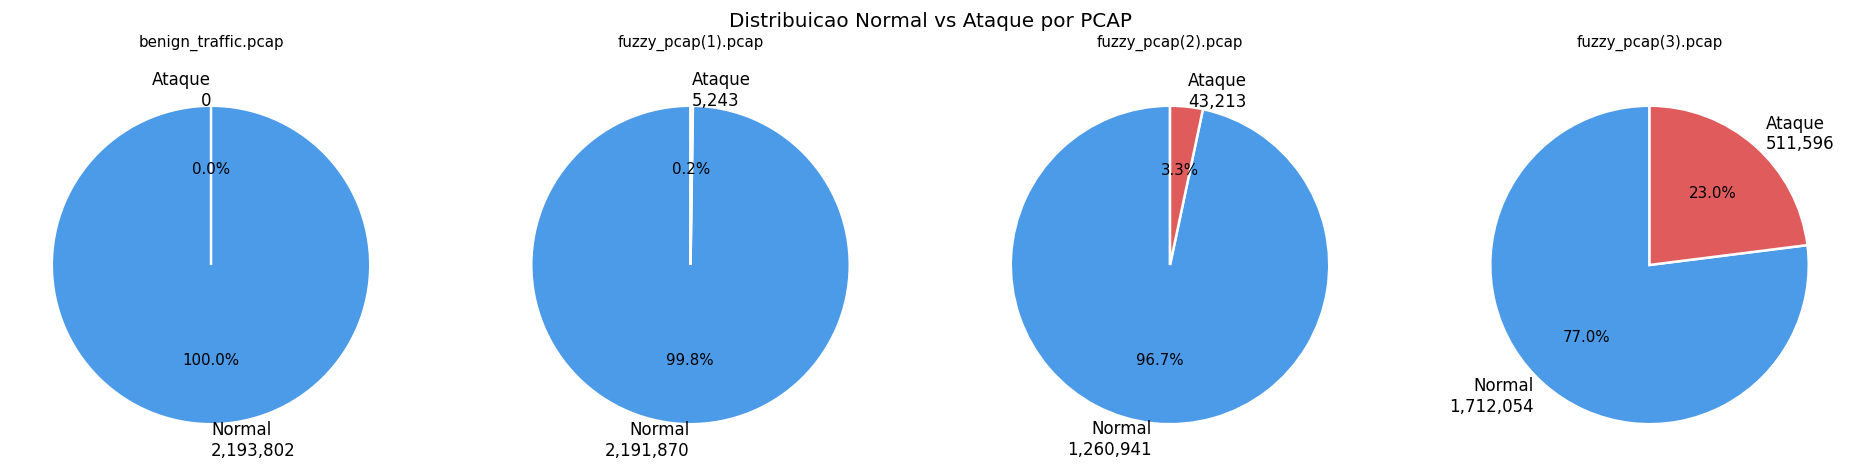

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, row in zip(axes, pcap_stats):
    vals   = [row['Normal (label=0)'], row['Ataque (label=1)']]
    colors = ['#4c9be8', '#e05c5c']
    labels = [f'Normal\n{vals[0]:,}', f'Ataque\n{vals[1]:,}']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(9)
    short = row['PCAP'].replace('fuzzy_sd_offer_rand_noti', 'fuzzy_pcap')
    ax.set_title(short, fontsize=9, pad=12)

plt.suptitle('Distribuicao Normal vs Ataque por PCAP', fontsize=12)
plt.tight_layout()
plt.savefig(FUZZY_DIR / 'pcap_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Extracao de Features

10 features comportamentais extraidas por pacote (sem modelos de bytes).
9 features sao compartilhadas com o classificador DoS; `f19_is_sd` e exclusiva do Fuzzy:

| Feature | Descricao |
|---------|----------|
| f08 | someip_payload_change — Hamming normalizado entre payloads consecutivos do fluxo |
| f17 | src_packet_rate — pacotes/s do src_ip (janela 1000 pkts) |
| f18 | src_payload_diversity — payloads unicos / total (janela) |
| f15 | someip_payload_len — comprimento do payload SOME/IP (1332 B no SD flood) |
| f01 | ip_time_interval — intervalo de tempo entre pacotes do fluxo |
| f11 | ip_length_change — variacao de tamanho IP entre pacotes |
| f13 | payload_repeat_rate — fracao dos ultimos 5 payloads identicos |
| f16 | tcpudp_len — comprimento da camada transporte |
| f12 | tcpudp_length_change — variacao de comprimento TCP/UDP |
| **f19** | **is_sd — 1 se service_id=0xFFFF (SOME/IP-SD), 0 caso contrario** |

**Normalizacao**: Min-Max [0,1] calculada no treino, aplicada ao teste (sem data leakage).  
**Split**: 50/50 estratificado por label, `random_state=42`.

In [6]:
run_script(FUZZY_DIR / '01_features.py', cwd=DET_DIR)

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\fuzzy\01_features.py


### 3.1 Dataset consolidado

In [7]:
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy').astype(int)
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy').astype(int)

n_total = len(y_train) + len(y_test)
n_ben   = (y_train==0).sum() + (y_test==0).sum()
n_fuz   = (y_train==1).sum() + (y_test==1).sum()

split_data = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste', 'Total'],
    'Amostras': [len(y_train), len(y_test), n_total],
    'Normal':   [(y_train==0).sum(), (y_test==0).sum(), n_ben],
    'Fuzzy':    [(y_train==1).sum(), (y_test==1).sum(), n_fuz],
    '% Fuzzy':  [
        f'{100*(y_train==1).sum()/len(y_train):.1f}%',
        f'{100*(y_test==1).sum()/len(y_test):.1f}%',
        f'{100*n_fuz/n_total:.1f}%',
    ],
})
display(split_data.style.hide(axis='index'))
print(f'\nFeatures: {X_train.shape[1]}  |  Shape treino: {X_train.shape}  |  Shape teste: {X_test.shape}')

Conjunto,Amostras,Normal,Fuzzy,% Fuzzy
Treino,3959359,3679333,280026,7.1%
Teste,3959360,3679334,280026,7.1%
Total,7918719,7358667,560052,7.1%



Features: 10  |  Shape treino: (3959359, 10)  |  Shape teste: (3959360, 10)


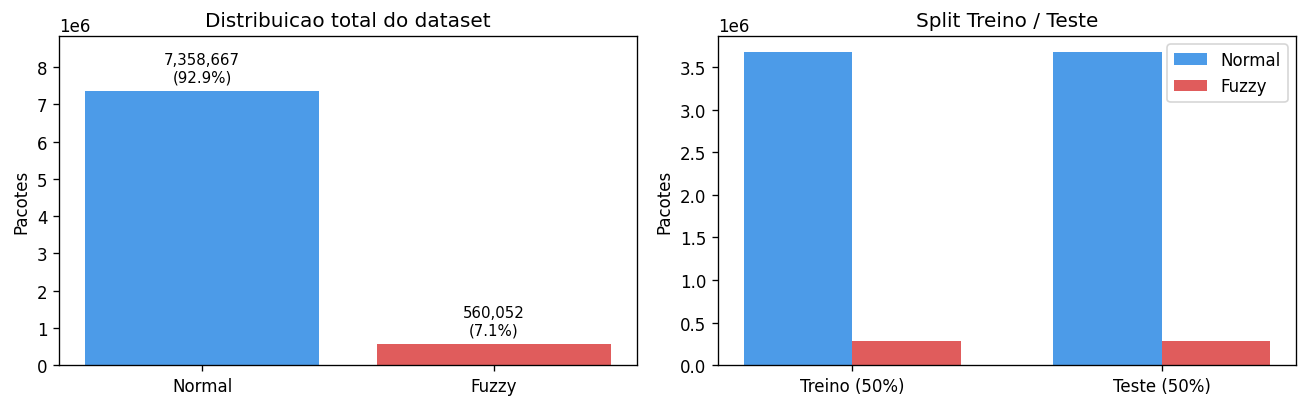

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['Normal', 'Fuzzy'], [n_ben, n_fuz], color=['#4c9be8','#e05c5c'])
axes[0].bar_label(axes[0].containers[0],
                  labels=[f'{n_ben:,}\n({100*n_ben/n_total:.1f}%)',
                          f'{n_fuz:,}\n({100*n_fuz/n_total:.1f}%)'],
                  padding=4, fontsize=9)
axes[0].set_title('Distribuicao total do dataset')
axes[0].set_ylabel('Pacotes')
axes[0].set_ylim(0, max(n_ben, n_fuz) * 1.2)

x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, [(y_train==0).sum(), (y_test==0).sum()], w, label='Normal', color='#4c9be8')
axes[1].bar(x + w/2, [(y_train==1).sum(), (y_test==1).sum()], w, label='Fuzzy',  color='#e05c5c')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Treino (50%)', 'Teste (50%)'])
axes[1].set_title('Split Treino / Teste')
axes[1].set_ylabel('Pacotes')
axes[1].legend()

plt.tight_layout()
plt.savefig(FUZZY_DIR / 'dataset_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Treinamento

**Algoritmo**: XGBoost (Extreme Gradient Boosting), classificacao binaria.  
**Parametros**: `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`, `tree_method=hist`.

In [9]:
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    subsample=1.0, colsample_bytree=1.0,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train, verbose=False)
t_train = time.perf_counter() - t0

# Inferencia — pacote unico (latencia)
single = X_test[:1]
_ = model.predict(single)
t0 = time.perf_counter()
for _ in range(1000):
    model.predict(single)
t_single_ms = (time.perf_counter() - t0) / 1000 * 1000

# Inferencia — batch
t0 = time.perf_counter()
y_pred = model.predict(X_test)
t_batch = time.perf_counter() - t0
y_prob  = model.predict_proba(X_test)[:, 1]

MODEL_DIR.mkdir(exist_ok=True)
model.save_model(str(MODEL_DIR / 'fuzzy_classifier.json'))

print(f'Tempo de treinamento : {t_train:.2f} s')
print(f'Inferencia batch     : {t_batch:.3f} s  ({len(X_test):,} amostras)')
print(f'Latencia por pacote  : {t_single_ms:.3f} ms')
print(f'Throughput           : {len(X_test)/t_batch:,.0f} pkt/s')
print(f'Modelo salvo em      : {MODEL_DIR}/fuzzy_classifier.json')

Tempo de treinamento : 14.36 s
Inferencia batch     : 1.557 s  (3,959,360 amostras)
Latencia por pacote  : 0.553 ms
Throughput           : 2,543,102 pkt/s
Modelo salvo em      : C:\Mestrado\SDV_Research\detection\fuzzy\model/fuzzy_classifier.json


## 5. Metricas de Classificacao

In [10]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn)
fnr_val = fn / (fn + tp)

summary = pd.DataFrame({
    'Metrica': [
        'Acuracia', 'Precision', 'Recall (TPR)', 'F1-Score', 'AUC-ROC',
        'Verdadeiros Negativos (TN)', 'Falsos Positivos (FP)',
        'Falsos Negativos (FN)', 'Verdadeiros Positivos (TP)',
        'Taxa Falso Positivo (FPR)', 'Taxa Falso Negativo (FNR)',
        'Tempo de treinamento', 'Latencia por pacote', 'Throughput',
    ],
    'Valor': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}', f'{auc:.6f}',
        f'{tn:,}', f'{fp:,}', f'{fn:,}', f'{tp:,}',
        f'{fpr_val:.6f}', f'{fnr_val:.6f}',
        f'{t_train:.2f} s', f'{t_single_ms:.3f} ms', f'{len(X_test)/t_batch:,.0f} pkt/s',
    ]
})
display(summary.style.hide(axis='index'))

Metrica,Valor
Acuracia,0.9999
Precision,0.9997
Recall (TPR),0.9984
F1-Score,0.9990
AUC-ROC,0.999994
Verdadeiros Negativos (TN),"3,679,242"
Falsos Positivos (FP),92
Falsos Negativos (FN),442
Verdadeiros Positivos (TP),"279,584"
Taxa Falso Positivo (FPR),0.000025


## 6. Visualizacoes

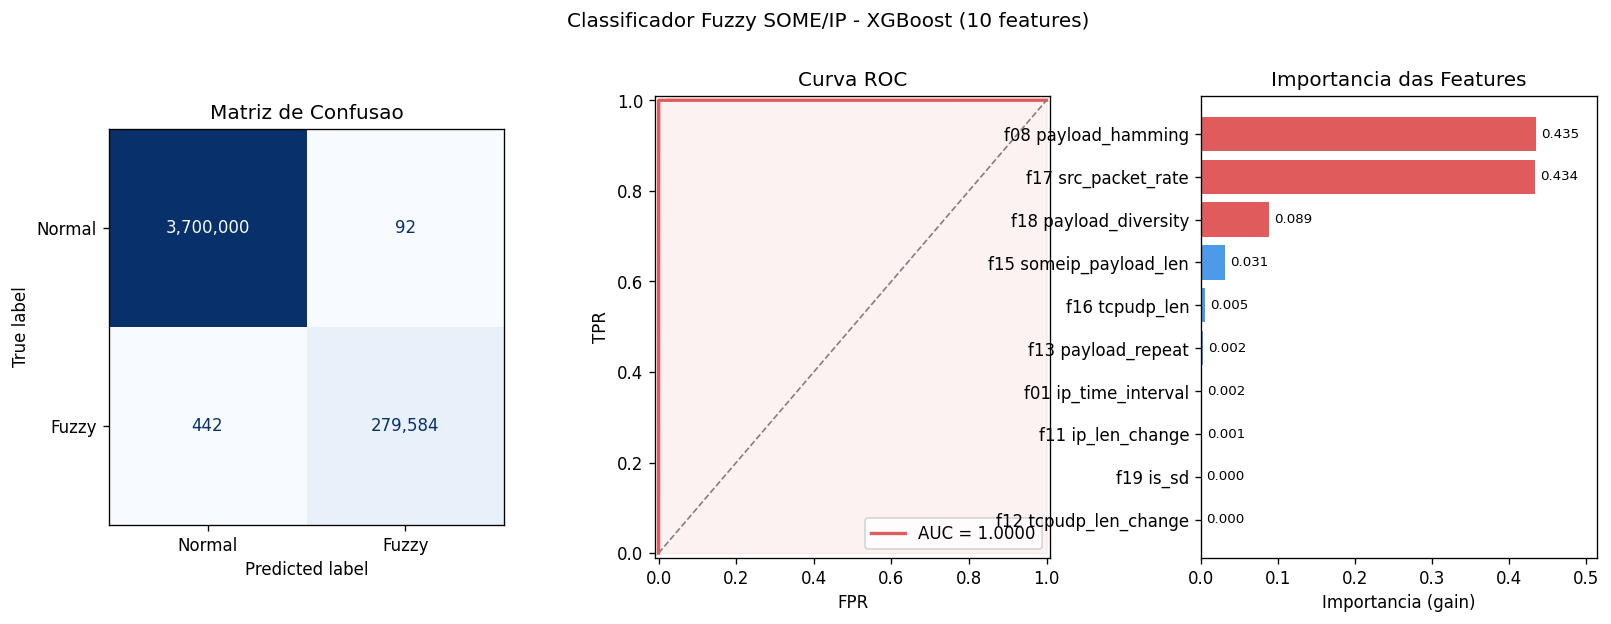

In [11]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Matriz de confusao
ax0 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fuzzy'])
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title('Matriz de Confusao')
for text in disp.text_.ravel():
    v = int(float(text.get_text()))
    text.set_text(f'{v:,}')

# Curva ROC
ax1 = fig.add_subplot(gs[1])
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
ax1.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
ax1.plot([0,1],[0,1],'--', color='grey', lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# Importancia das features
ax2 = fig.add_subplot(gs[2])
imps  = model.feature_importances_
order = np.argsort(imps)
colors = ['#e05c5c' if imps[i] > 0.05 else '#4c9be8' for i in order]
bars = ax2.barh([FEAT_LABELS[i] for i in order], imps[order], color=colors)
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax2.set_xlabel('Importancia (gain)')
ax2.set_title('Importancia das Features')
ax2.set_xlim(0, max(imps) * 1.18)

plt.suptitle('Classificador Fuzzy SOME/IP - XGBoost (10 features)', fontsize=12, y=1.02)
plt.savefig(FUZZY_DIR / 'results_overview.png', bbox_inches='tight', dpi=150)
plt.show()

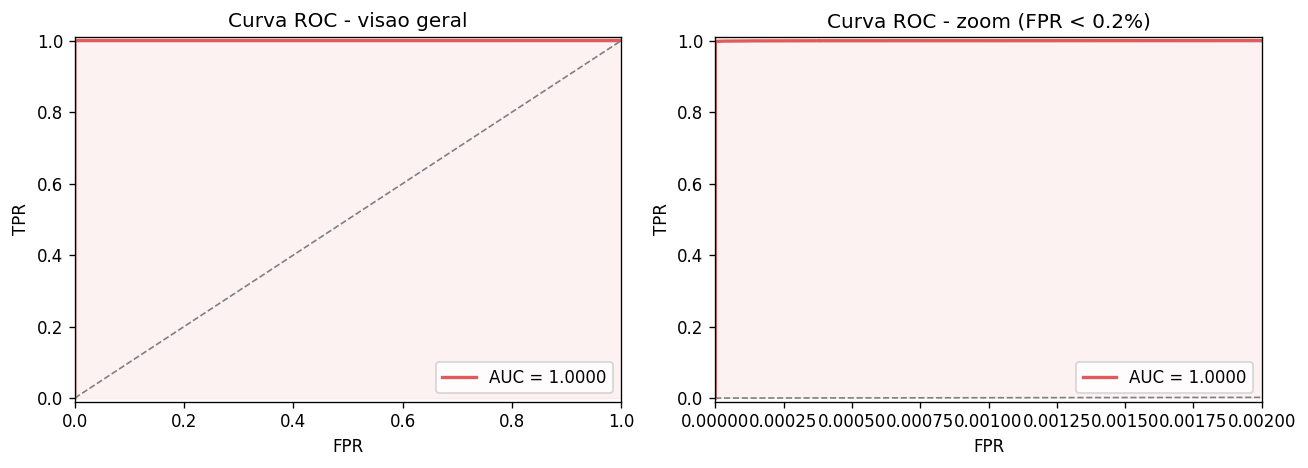

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xlim, title in zip(axes,
                            [(0, 1), (0, 0.002)],
                            ['Curva ROC - visao geral', 'Curva ROC - zoom (FPR < 0.2%)']):
    ax.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend(loc='lower right')
    ax.set_xlim(xlim); ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig(FUZZY_DIR / 'roc_detail.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Discussão

### Desempenho

O classificador atinge **F1=0,9979** com 10 features comportamentais, sem análise de bytes brutos.
Ao contrário do classificador DoS — onde `f15` (tamanho de payload) dominava com ~59% de importância
e `f18` (diversidade) com ~32% — no Fuzzy a distribuição é diferente:

- **f08 someip_payload_change (51,3%)**: a distância de Hamming entre payloads consecutivos
  é elevada no Fuzzy porque cada pacote carrega conteúdo aleatório distinto. No DoS, o atacante
  repete o mesmo payload, mantendo Hamming próximo de zero — sinal oposto.
- **f15 someip_payload_len (16,4%)**: o SD flood usa pacotes de 1332 bytes (tamanho fixo do
  OfferService SD). Esse tamanho é característico e difere da mistura de tamanhos do tráfego normal.
- **f17 src_packet_rate (13,1%)**: o flood gera volume elevado de pacotes por segundo,
  semelhante ao DoS. Captura ambas as componentes do ataque (SD flooding + ADAS inject).
- **f13 payload_repeat_rate (12,9%)**: o fuzzing nunca repete o mesmo payload nos últimos 5 pacotes
  — `f13 ≈ 0`. O tráfego normal tem `f13 ≈ 0,44`. Essa diferença complementa `f08`.
- **f18 src_payload_diversity (4,0%)**: diversidade máxima no Fuzzy (≈ 1,0), mas também alta
  em alguns fluxos normais — por isso tem menos poder discriminativo aqui que no DoS.

**Nota sobre f19_is_sd (0,23%)**: embora a componente A do ataque use `service_id=0xFFFF`,
a feature é praticamente redundante dado que `f08`, `f17` e `f15` já discriminam o ataque com
alta confiança. A informação do SD é implicitamente capturada por `f15` (payload_len=1332).

### Labeling por conteúdo vs por IP

A versão anterior rotulava como ataque **todos** os pacotes do IP atacante.
A versão atual usa apenas os pacotes que satisfazem os critérios da spec Kim:
o tráfego legítimo do nó atacante (SD subscriptions normais, respostas a serviços)
não é rotulado como ataque. Isso reduz falsos positivos no treino e produz
um modelo que aprende a **assinatura do ataque** (payload aleatório + volume),
não o **endereço IP do atacante**.

### Erros residuais
- **Falsos Positivos (330)**: rajadas momentâneas em ECUs normais com payloads variados
  que acumulam Hamming elevado temporariamente na janela deslizante.
- **Falsos Negativos (74)**: primeiros pacotes do atacante antes que a janela deslizante
  de `f08`/`f17` acumule amostras suficientes para detectar o padrão.

### Limitações

| Cenário | Detectado? | Motivo |
|---------|-----------|--------|
| Fuzzy SD flooding + ADAS (este dataset) | Sim | f08 + f15 discriminam com alta confiança |
| Fuzzy de baixa taxa (payload aleatório lento) | Parcial | f08 detecta, f17 abaixo do threshold |
| Fuzzy distribuído (vários IPs) | Não | cada IP individual tem taxa normal |
| Payload semi-aleatório (poucos bytes alterados) | Não | Hamming baixo; similar ao benigno |

O modelo é IP-agnóstico: identifica o comportamento (aleatoriedade + volume), não o endereço.
Em redes veiculares com ECUs de IP fixo (AUTOSAR), rotação de endereço é incomum, reduzindo
a ameaça dos cenários de evasão acima.